# 3. Support Vector Machine (SVM)

## Descrição
Support Vector Machine é um algoritmo de classificação que encontra o hiperplano ótimo que maximiza a margem entre as classes. Utiliza kernel RBF para capturar relações não-lineares nos dados.

## Características
- Classificador com kernel não-linear
- Maximiza margem de separação
- Eficiente em altas dimensões
- Modelo do trabalho original

## Referências
- Vapnik, V. N. (1995). The Nature of Statistical Learning Theory. Springer-Verlag.

## 1. Importações

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import os
from pathlib import Path

# Paths agnósticos
def get_project_root():
    path = Path.cwd()
    for _ in range(6):
        if (path / 'dados' / 'data_treino.csv').exists() or (path / 'data_treino.csv').exists(): return path
        if (path / 'dados' / 'processados').is_dir(): return path
        path = path.parent
    return Path.cwd()
PROJECT_ROOT = get_project_root()
DIR_DADOS_PROCESSADOS = PROJECT_ROOT / 'dados' / 'processados'
DIR_MODELOS = PROJECT_ROOT / 'modelos'
DIR_GRAFICOS = PROJECT_ROOT / 'graficos'

from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, precision_recall_curve, f1_score, accuracy_score,
    precision_score, recall_score, auc
)
import joblib

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)

os.makedirs(DIR_GRAFICOS, exist_ok=True)
os.makedirs(DIR_MODELOS, exist_ok=True)

## 2. Carregamento dos Dados

In [9]:
with open(DIR_DADOS_PROCESSADOS / 'datasets.pkl', 'rb') as f:
    datasets = pickle.load(f)

X_train = datasets['baseline']['X_train']
X_val = datasets['baseline']['X_val']
X_test = datasets['baseline']['X_test']
y_train = datasets['baseline']['y_train']
y_val = datasets['baseline']['y_val']
y_test = datasets['baseline']['y_test']

print(f"Dados carregados: {X_train.shape}")

Dados carregados: (1730, 50)


## 3. Otimização de Hiperparâmetros

In [10]:
param_dist = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'degree': [2, 3, 4],
    'class_weight': ['balanced', None]
}

svm_base = SVC(probability=True, random_state=42)

random_search = RandomizedSearchCV(
    svm_base,
    param_dist,
    n_iter=40,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Treinando SVM...")
random_search.fit(X_train, y_train)

print(f"\nMelhores parâmetros: {random_search.best_params_}")
print(f"Melhor F1-score: {random_search.best_score_:.4f}")

Treinando SVM...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Melhores parâmetros: {'kernel': 'rbf', 'gamma': 'scale', 'degree': 2, 'class_weight': None, 'C': 0.1}
Melhor F1-score: 0.7115


## 4. Avaliação

In [11]:
svm_model = random_search.best_estimator_

y_test_pred = svm_model.predict(X_test)
y_test_pred_proba = svm_model.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_pred_proba)

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_test_pred_proba)
test_pr_auc = auc(recall_vals, precision_vals)

print("="*60)
print("MÉTRICAS - SVM")
print("="*60)
print(f"F1-Score: {test_f1:.4f}")
print(f"ROC-AUC: {test_roc_auc:.4f}")
print(f"Acurácia: {test_accuracy:.4f}")
print(f"Precisão: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"PR-AUC: {test_pr_auc:.4f}")
print("="*60)

MÉTRICAS - SVM
F1-Score: 0.7143
ROC-AUC: 0.6411
Acurácia: 0.5699
Precisão: 0.5634
Recall: 0.9756
PR-AUC: 0.6871


## 5. Visualizações

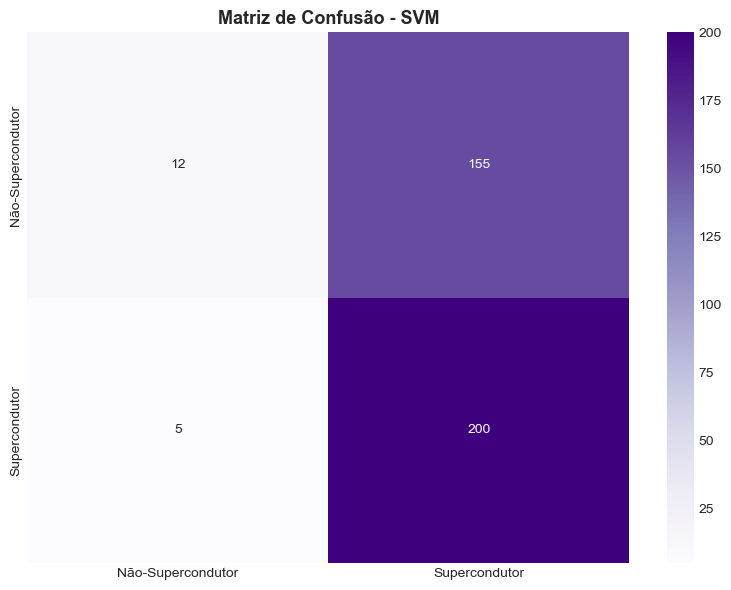

In [12]:
# Matriz de Confusão
cm = confusion_matrix(y_test, y_test_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=True, ax=ax,
            xticklabels=['Não-Supercondutor', 'Supercondutor'],
            yticklabels=['Não-Supercondutor', 'Supercondutor'])
ax.set_title('Matriz de Confusão - SVM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(DIR_GRAFICOS / '03_svm_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

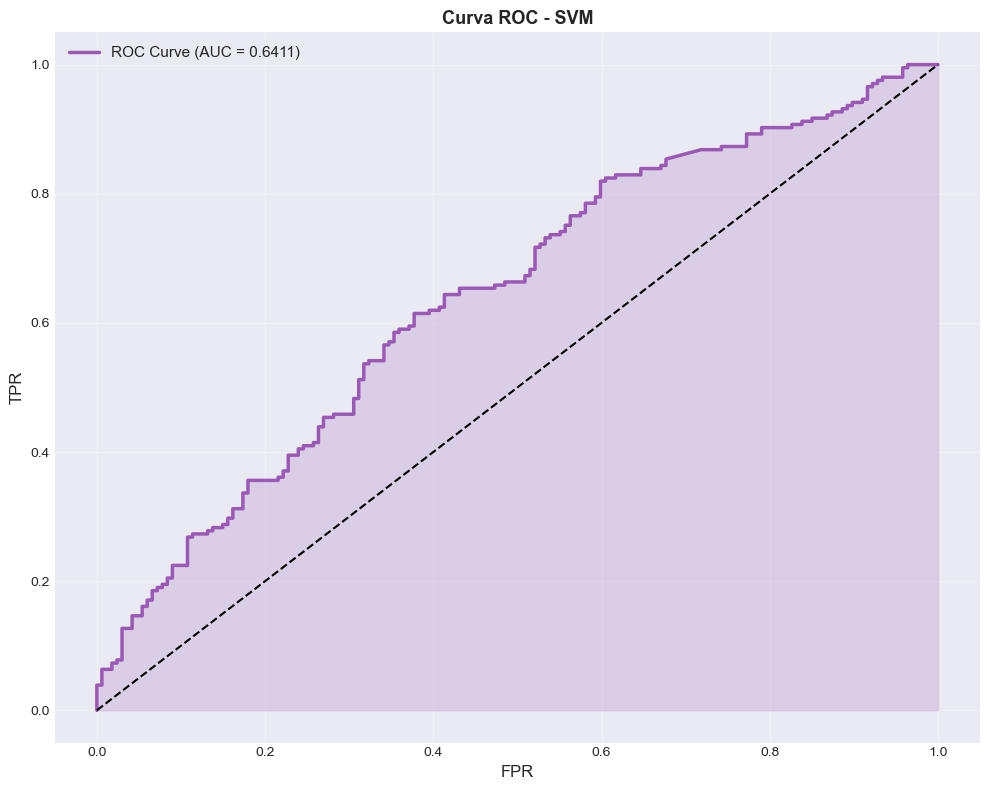

In [13]:
# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_test_pred_proba)
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(fpr, tpr, label=f'ROC Curve (AUC = {test_roc_auc:.4f})', linewidth=2.5, color='#9B59B6')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5)
ax.fill_between(fpr, tpr, alpha=0.2, color='#9B59B6')
ax.set_xlabel('FPR', fontsize=12)
ax.set_ylabel('TPR', fontsize=12)
ax.set_title('Curva ROC - SVM', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(DIR_GRAFICOS / '03_svm_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Salvamento

In [14]:
joblib.dump(svm_model, DIR_MODELOS / 'svm_model.pkl')

results = {
    'model_name': 'SVM',
    'best_params': random_search.best_params_,
    'metrics': {
        'test_accuracy': test_accuracy,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'test_f1': test_f1,
        'test_roc_auc': test_roc_auc,
        'test_pr_auc': test_pr_auc
    },
    'predictions': {
        'y_test_pred': y_test_pred,
        'y_test_pred_proba': y_test_pred_proba
    }
}

with open(DIR_MODELOS / 'svm_results.pkl', 'wb') as f:
    pickle.dump(results, f)

print("Modelo SVM salvo com sucesso!")

Modelo SVM salvo com sucesso!
